In [33]:
import pandas as pd

# Carica il dataset
df = pd.read_csv('trainspace.csv')

# Visualizza le prime 5 righe per controllare che sia tutto ok
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [34]:
print(df.tail())
print('---------------')
print(df.describe())


     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
8688          0.0     6819.0           0.0  1643.0    74.0  Gravior Noxnuther   
8689          0.0        0.0           0.0     0.0     0.0    Kurta Mondalley   
8690          0.0        0.0        1872.0     1.0     0.0       Fayey Connon   
8691          0.0     1049.0           0.0   353.0  3235.0   Celeon Hontichre   
8692        126.0     4688.0           0.0     0.0    12.0   Propsh Hontichre   

      Transported  
8688        False 

In [35]:
print(df.info())
print('----------')
print(df.isnull().sum()/len(df)*100)

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None
----------
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age 

In [36]:
# 1. Crea la copia e pulisci direttamente quella
df_cleaned = df.dropna().copy()

# 2. Reset dell'indice sulla copia pulita
df_cleaned.reset_index(drop=True, inplace=True)
print(df_cleaned.isnull().sum())
df=df_cleaned
'''df_cleaned = df.copy()
df_cleaned.dropna()
print(df_cleaned.head())
print(df_cleaned.isnull().sum())
print('---')
print(df_cleaned.dropduplicate().sum())'''

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


"df_cleaned = df.copy()\ndf_cleaned.dropna()\nprint(df_cleaned.head())\nprint(df_cleaned.isnull().sum())\nprint('---')\nprint(df_cleaned.dropduplicate().sum())"

In [37]:
df = df.drop(columns=['PassengerId','Name'])
df.info()
#print(df['Name'])

<class 'pandas.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    6606 non-null   str    
 1   CryoSleep     6606 non-null   object 
 2   Cabin         6606 non-null   str    
 3   Destination   6606 non-null   str    
 4   Age           6606 non-null   float64
 5   VIP           6606 non-null   object 
 6   RoomService   6606 non-null   float64
 7   FoodCourt     6606 non-null   float64
 8   ShoppingMall  6606 non-null   float64
 9   Spa           6606 non-null   float64
 10  VRDeck        6606 non-null   float64
 11  Transported   6606 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(3)
memory usage: 574.3+ KB


In [38]:
# Converte i booleani in 0 e 1
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['Transported'] = df['Transported'].astype(int)

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HomePlanet    6606 non-null   category
 1   CryoSleep     6606 non-null   int64   
 2   Cabin         6606 non-null   category
 3   Destination   6606 non-null   category
 4   Age           6606 non-null   float64 
 5   VIP           6606 non-null   int64   
 6   RoomService   6606 non-null   float64 
 7   FoodCourt     6606 non-null   float64 
 8   ShoppingMall  6606 non-null   float64 
 9   Spa           6606 non-null   float64 
 10  VRDeck        6606 non-null   float64 
 11  Transported   6606 non-null   int64   
dtypes: category(3), float64(6), int64(3)
memory usage: 531.9 KB


C:\Users\Mary_Rosy\AppData\Local\Temp\ipykernel_16048\1166362994.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


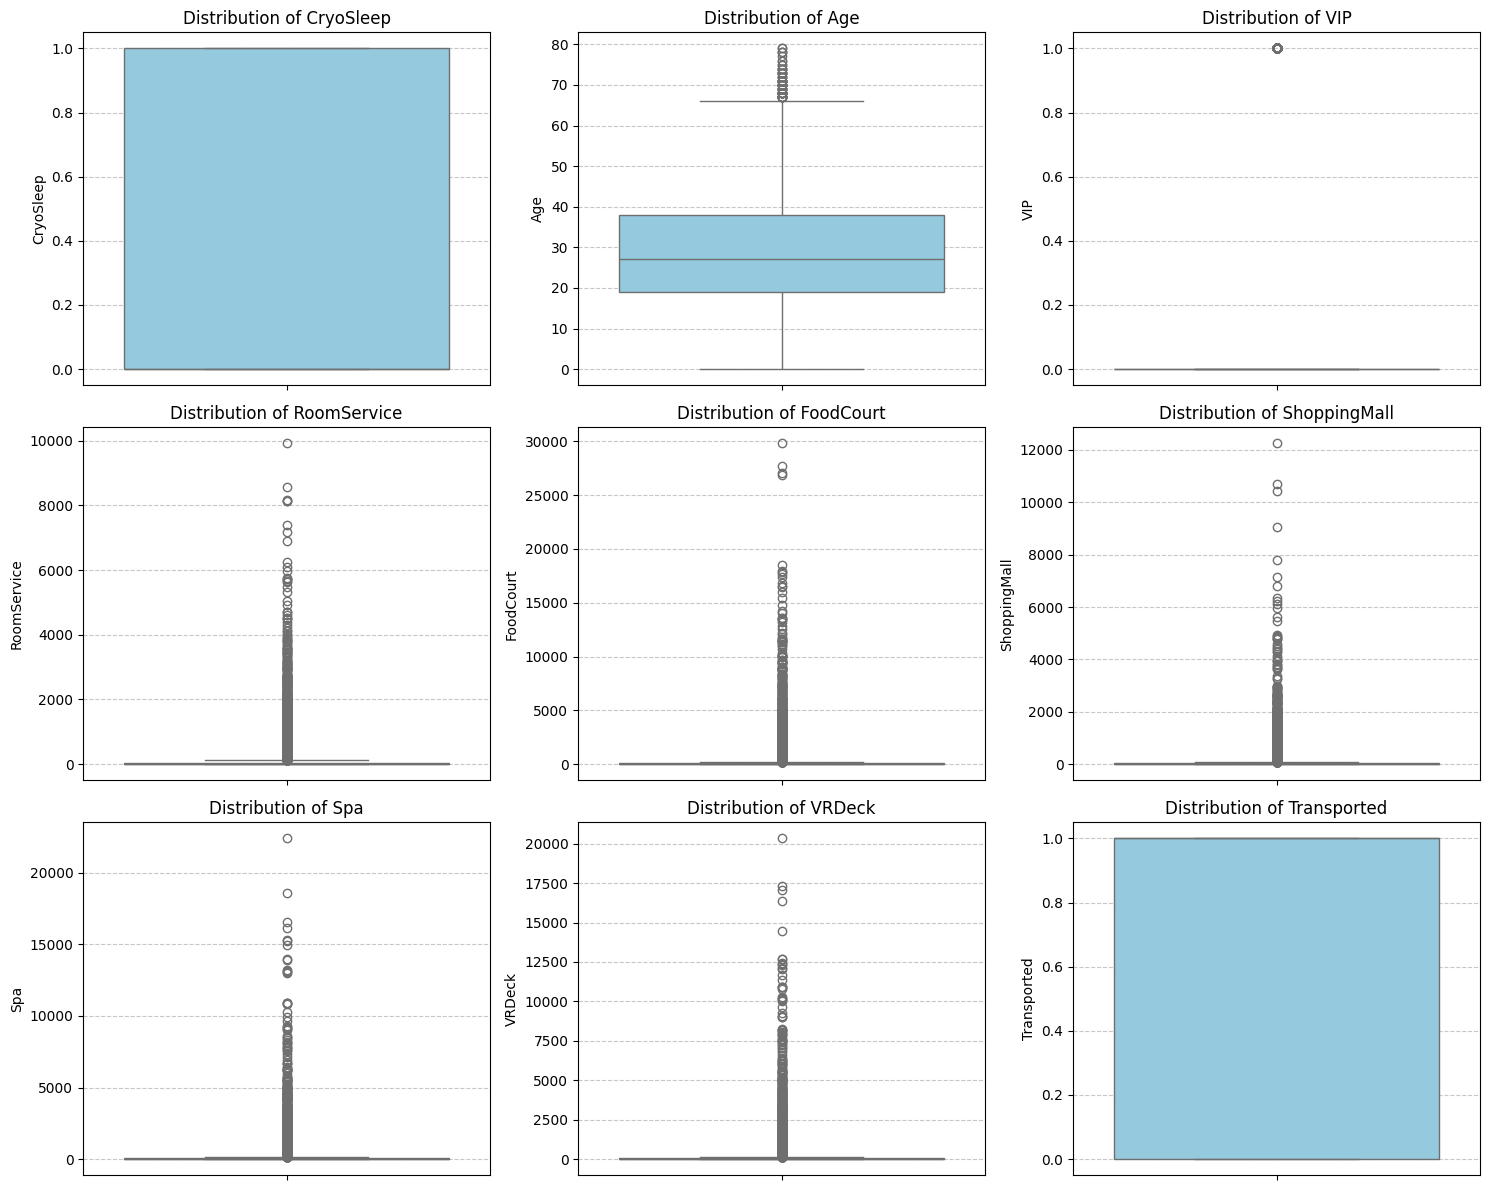

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid dimensions (e.g., 3 columns per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Final adjustments and saving
plt.tight_layout()
plt.savefig('numeric_boxplots.png')

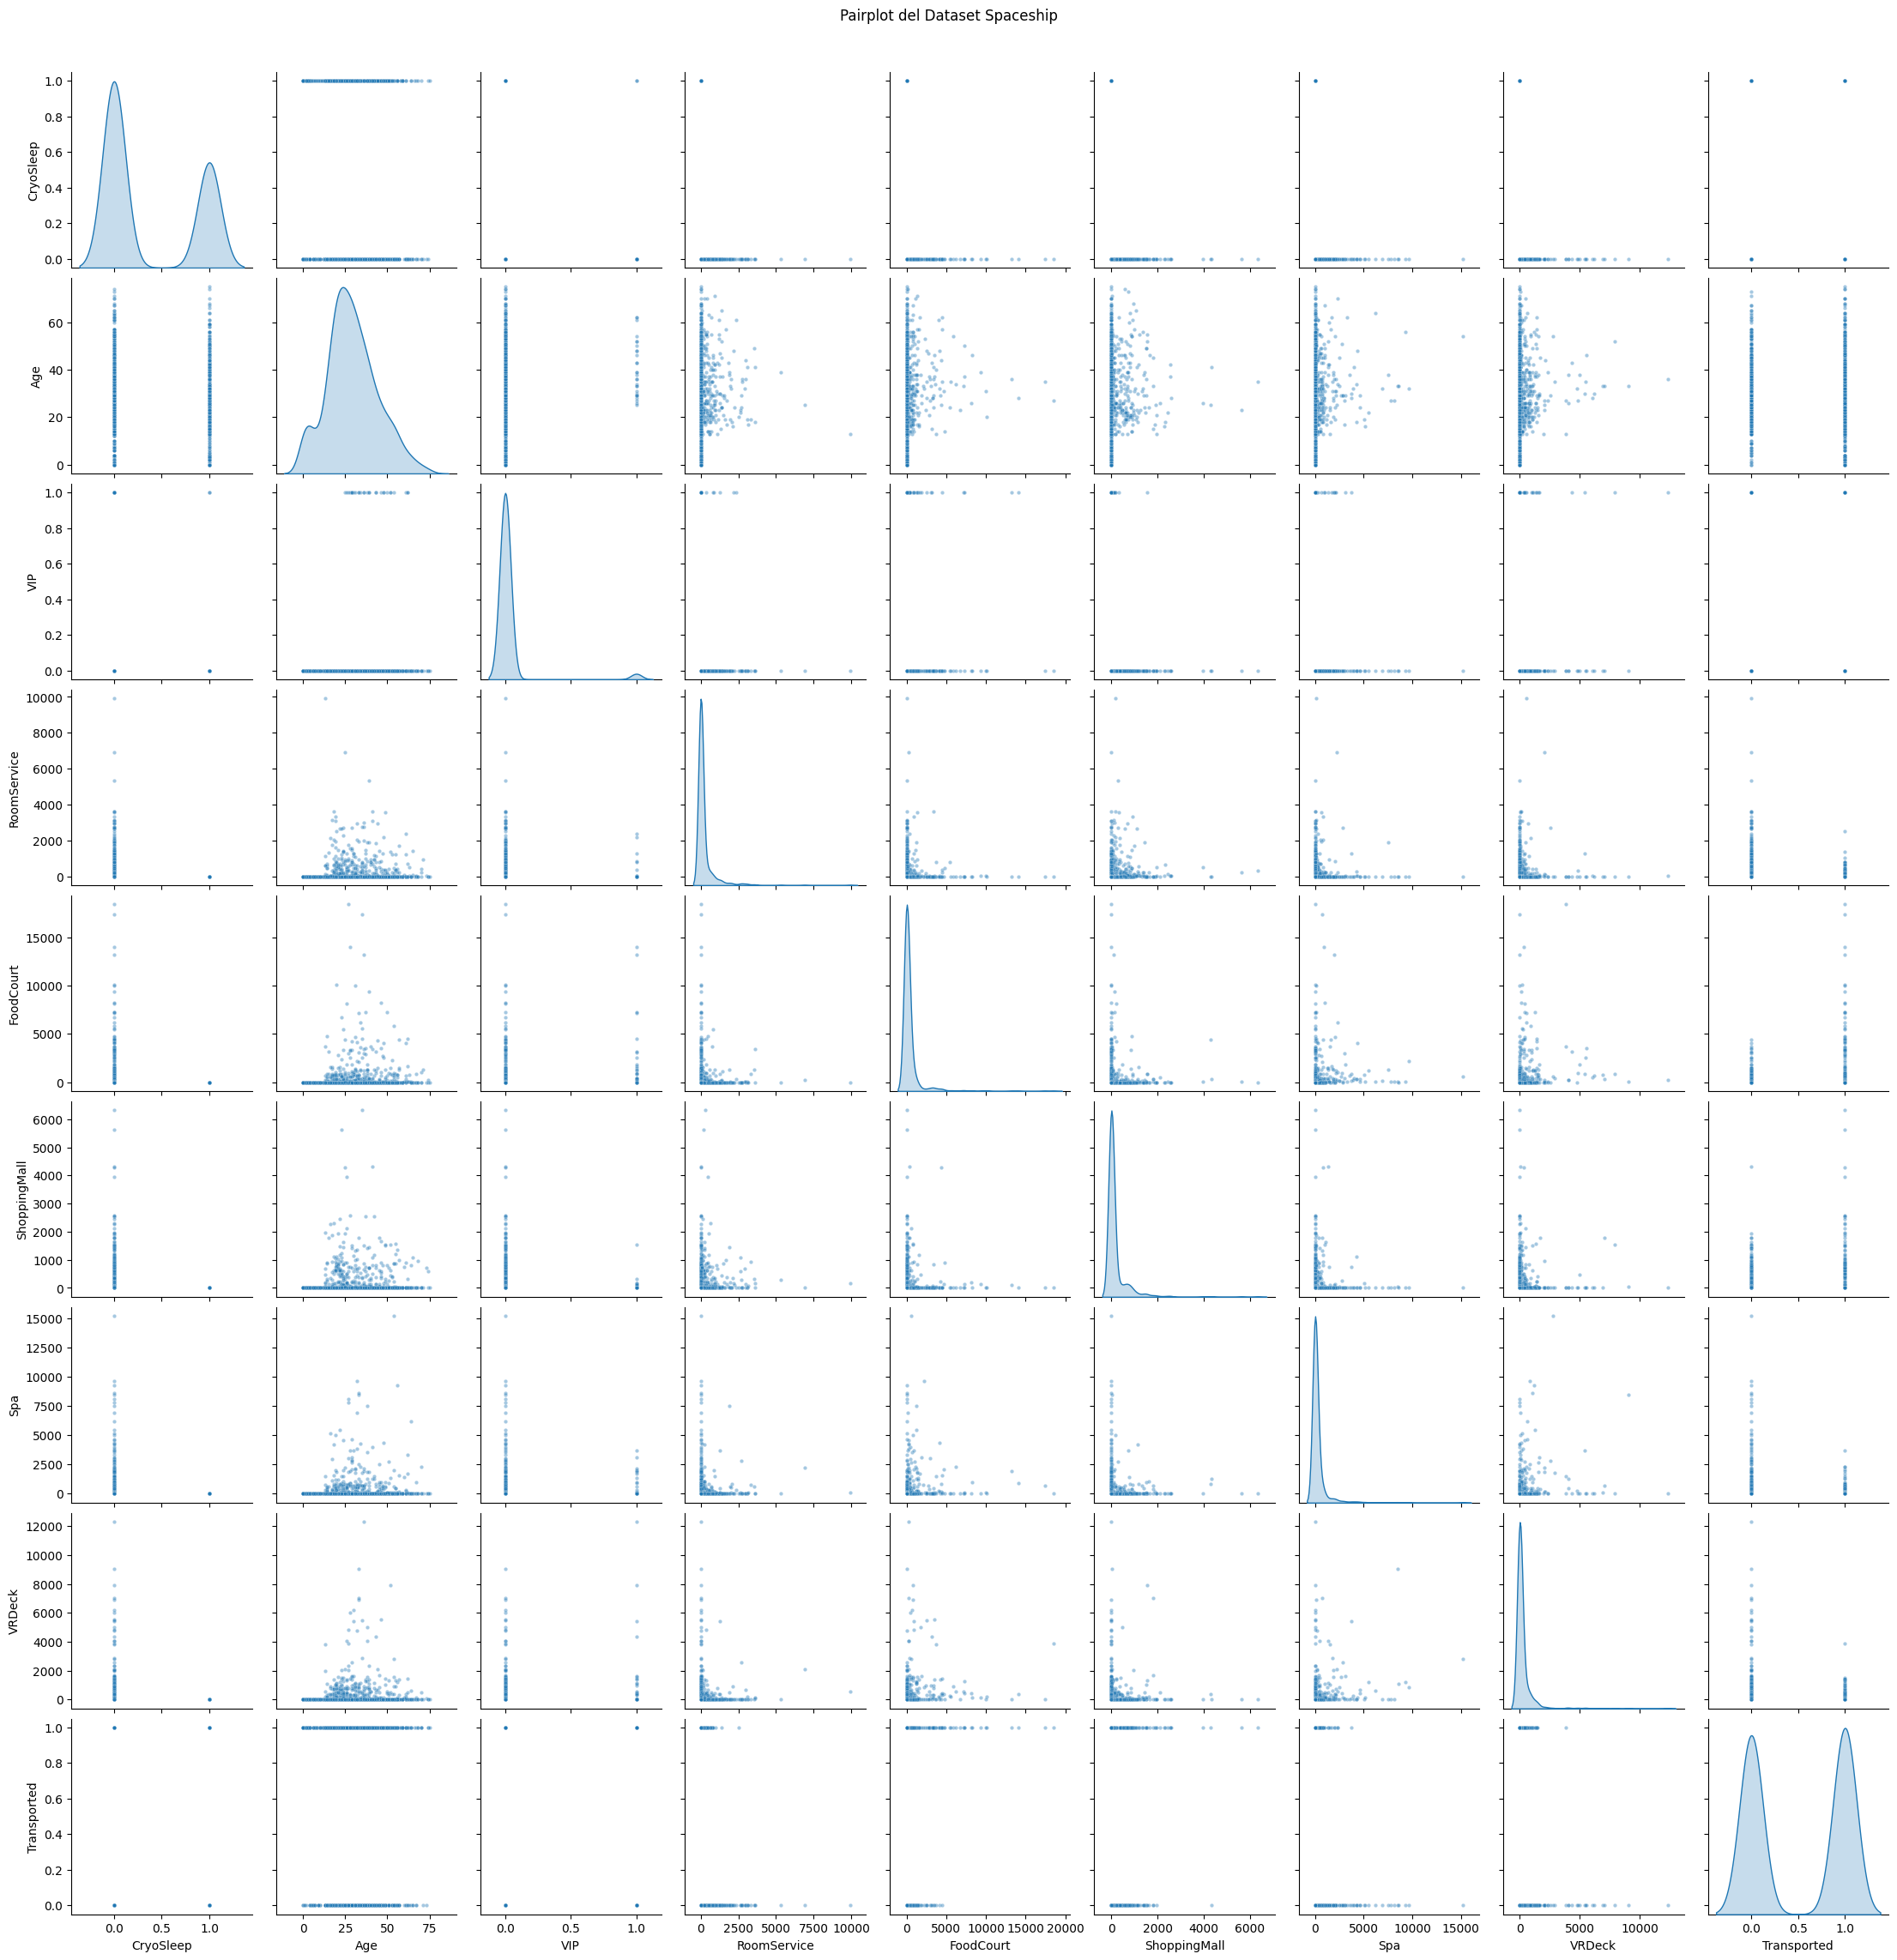

In [40]:
#Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample =df.sample(n=1000, random_state=42)

#Creazione del Pairplot
#'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
#'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample, 
             diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset Spaceship", y=1.02)
plt.show()

In [41]:
import pandas as pd

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        # Calcolo dei quartili (Standard: 0.15 e 0.85)
        Q1 = df_clean[col].quantile(0.15)
        Q3 = df_clean[col].quantile(0.85)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Il filtraggio DEVE stare dentro il ciclo per pulire colonna per colonna
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    return df_clean

# Definiamo le colonne su cui applicare il metodo (quelle con alta varianza nel Pairplot)
colonne_outlier = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Applichiamo la funzione
df_iqr = remove_outliers_iqr(df_cleaned, colonne_outlier)

print(f"Passeggeri totali originali: {len(df_cleaned)}")
print(f"Passeggeri dopo rimozione outlier: {len(df_iqr)}")
print(f"Righe rimosse: {len(df_cleaned) - len(df_iqr)}")

Passeggeri totali originali: 6606
Passeggeri dopo rimozione outlier: 4441
Righe rimosse: 2165


### creazione feature

In [42]:
import numpy as np

# Lista delle colonne monetarie
spese_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Applicazione della trasformazione logaritmica (log1p = log(1+x))
for col in spese_cols:
    df[col] = np.log1p(df[col])

# Ora se visualizzi il boxplot, vedrai una distribuzione molto più "umana"

In [43]:
df['TotalSpending'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
df['HasSpent'] = (df['TotalSpending'] > 0).astype(int)
# Esempio di estrazione (esegui prima di dropna o gestisci i nulli)
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

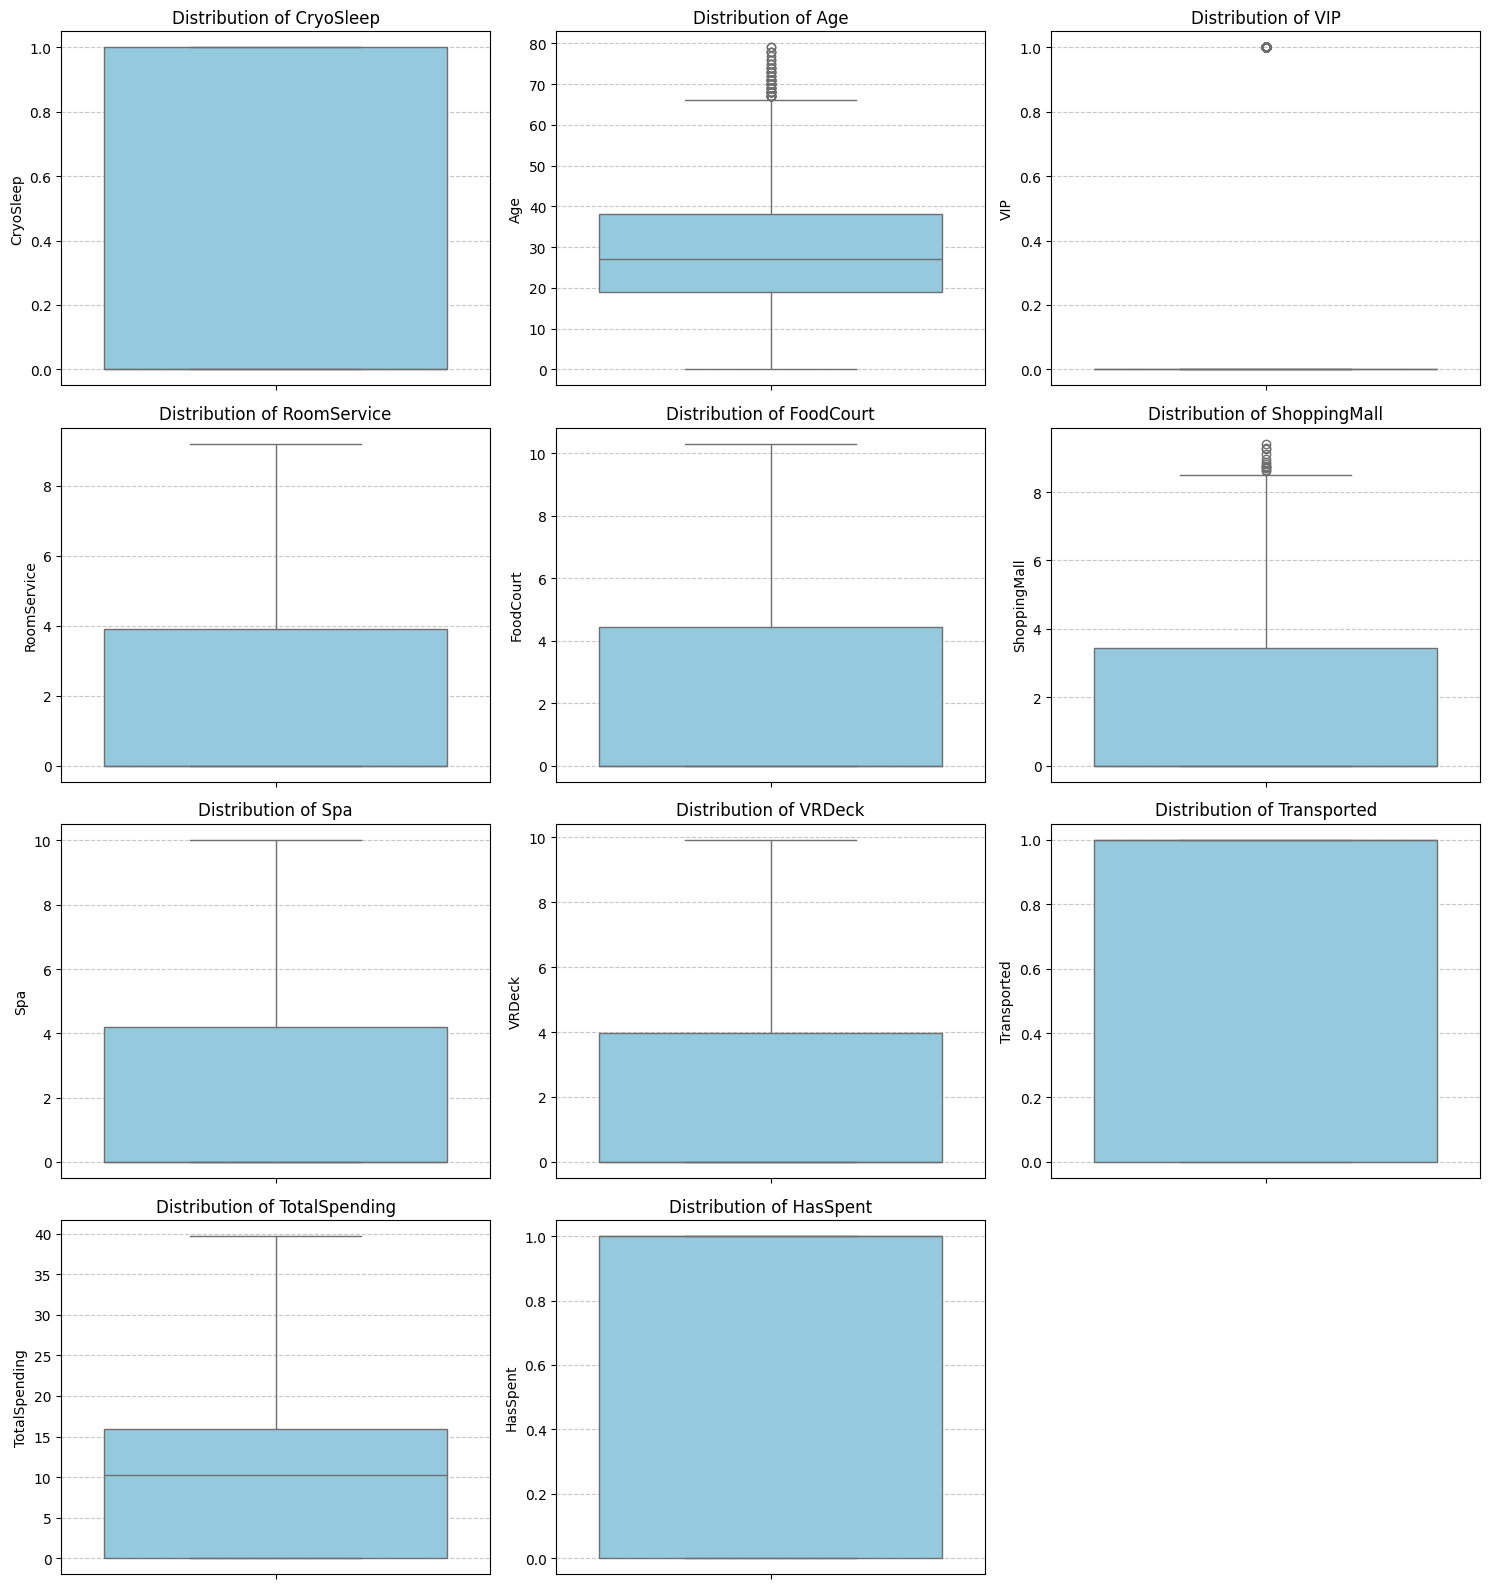

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid dimensions (e.g., 3 columns per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Final adjustments and saving
plt.tight_layout()
plt.savefig('numeric_boxplots.png')

### classificazione con xgboost e optuna

[I 2026-03-04 17:46:47,503] A new study created in memory with name: no-name-d8bd9c33-4871-4d16-8527-2a8e4b6af98e
[I 2026-03-04 17:46:51,104] Trial 0 finished with value: 0.81089258698941 and parameters: {'n_estimators': 704, 'max_depth': 5, 'learning_rate': 0.07781877898288907, 'subsample': 0.6164763189050799, 'colsample_bytree': 0.8032663822813847, 'gamma': 0.780978341572871, 'reg_lambda': 0.0017001636624864754}. Best is trial 0 with value: 0.81089258698941.
[I 2026-03-04 17:46:55,887] Trial 1 finished with value: 0.8154311649016641 and parameters: {'n_estimators': 816, 'max_depth': 6, 'learning_rate': 0.05270537292349234, 'subsample': 0.7305813341934412, 'colsample_bytree': 0.6150073397211462, 'gamma': 0.5232697378289414, 'reg_lambda': 0.018398519540911155}. Best is trial 1 with value: 0.8154311649016641.
[I 2026-03-04 17:46:56,845] Trial 2 finished with value: 0.8018154311649016 and parameters: {'n_estimators': 373, 'max_depth': 3, 'learning_rate': 0.07080987460227314, 'subsample':

Miglior accuratezza trovata: 0.8245


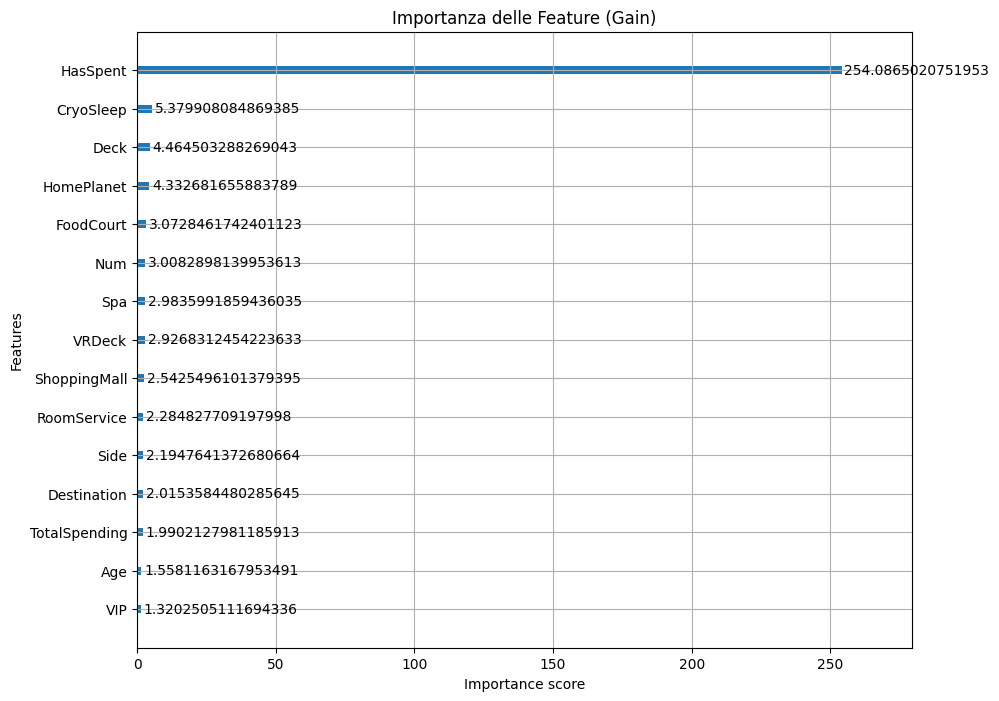

'import pandas as pd\nimport numpy as np\nimport xgboost as xgb\nimport optuna\nimport matplotlib.pyplot as plt\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import accuracy_score\n\n# --- SISTEMAZIONE DATI ---\n# 1. Rimuoviamo colonne inutili se ancora presenti (PassengerId, Name)\nX = df.drop(columns=[\'Transported\', \'PassengerId\', \'Name\', \'Cabin\'], errors=\'ignore\')\ny = df[\'Transported\'].astype(int) # Assicuriamoci che il target sia 0/1\n\n# 2. Trasformiamo TUTTE le colonne di testo rimaste in tipo \'category\'\n# Questo risolve l\'errore KeyError: \'str\'\nfor col in X.select_dtypes(include=[\'object\', \'string\']).columns:\n    X[col] = X[col].astype(\'category\')\n\n# 3. Split dei dati\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# --- DEFINIZIONE OPTUNA ---\ndef objective(trial):\n    param = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 100, 1000),\n        \'max_depth\

In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- 1. PREPARAZIONE DATI (Risolve il problema del primo codice) ---
# Rimuoviamo le colonne "testuali" che non servono e il target
colonne_inutili = ['PassengerId', 'Name', 'Cabin', 'Transported']
X = df.drop(columns=[c for c in colonne_inutili if c in df.columns])
y = df['Transported'].astype(int)

# CONVERSIONE STRINGHE: Trasformiamo Deck, Num, Side ecc. in 'category'
# Senza questo, XGBoost darà sempre errore KeyError: 'str'
for col in X.select_dtypes(include=['object', 'string', 'category']).columns:
    X[col] = X[col].astype('category')

# Split dei dati (X e y sono ora puliti e compatibili)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. DEFINIZIONE OBIETTIVO OPTUNA ---
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'objective': 'binary:logistic',
        'random_state': 42,
        'tree_method': 'hist',
        'enable_categorical': True, # Abilita la gestione automatica delle categorie
        'device': 'cpu',
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_valid)
    return accuracy_score(y_valid, preds)

# --- 3. OTTIMIZZAZIONE ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Miglior accuratezza trovata: {study.best_value:.4f}")

# --- 4. MODELLO FINALE ---
# Recuperiamo i parametri migliori e aggiungiamo quelli fissi di sistema
params = study.best_params
params['enable_categorical'] = True
params['tree_method'] = 'hist'
params['device'] = 'cpu'

best_model = xgb.XGBClassifier(**params)
best_model.fit(X_train, y_train)

# --- 5. GRAFICO IMPORTANZA (Il "grafico migliore" che volevi) ---
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type='gain', ax=plt.gca(), title='Importanza delle Feature (Gain)')
plt.grid(True)
plt.show()





#Attenzione: I parametri restituiti da study.best_params
#  sono solo quelli ottimizzati. I parametri di sistema come 
# enable_categorical=True e tree_method='hist' devono essere passati 
# esplicitamente anche al modello finale prima del .fit(), altrimenti il DataFrame verrà rifiutato.
'''import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- SISTEMAZIONE DATI ---
# 1. Rimuoviamo colonne inutili se ancora presenti (PassengerId, Name)
X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'], errors='ignore')
y = df['Transported'].astype(int) # Assicuriamoci che il target sia 0/1

# 2. Trasformiamo TUTTE le colonne di testo rimaste in tipo 'category'
# Questo risolve l'errore KeyError: 'str'
for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = X[col].astype('category')

# 3. Split dei dati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- DEFINIZIONE OPTUNA ---
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'objective': 'binary:logistic',
        'random_state': 42,
        'tree_method': 'hist',
        'enable_categorical': True, # Fondamentale per le colonne 'category'
        'device': 'cpu',
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    # Corretto x_test in X_test (Python è case-sensitive)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# 4. Lancio dello studio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Miglior accuratezza trovata: {study.best_value:.4f}")

# --- MODELLO FINALE ---
# Usiamo i migliori parametri trovati per l'addestramento definitivo
best_model = xgb.XGBClassifier(**study.best_params, enable_categorical=True, tree_method='hist')
best_model.fit(X_train, y_train)

# 6. Visualizzazione dell'importanza delle Feature
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type='gain', ax=plt.gca(), title='Importanza delle Feature (Gain)')
plt.show()'''

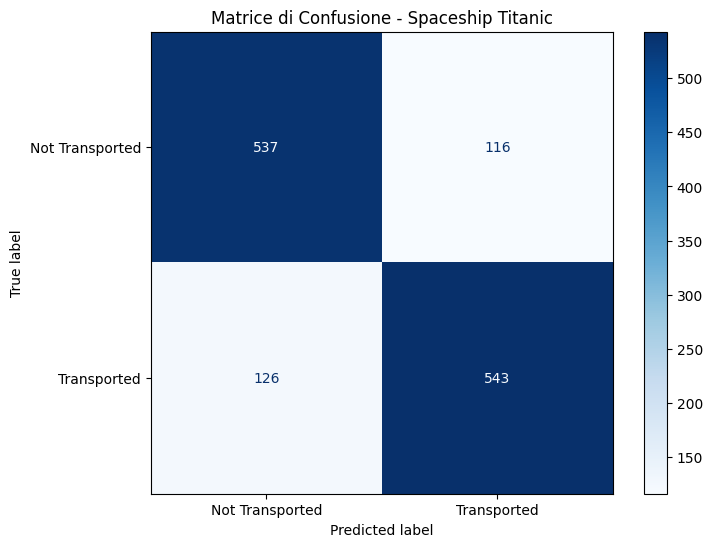


--- REPORT DI CLASSIFICAZIONE ---
                 precision    recall  f1-score   support

Not Transported       0.81      0.82      0.82       653
    Transported       0.82      0.81      0.82       669

       accuracy                           0.82      1322
      macro avg       0.82      0.82      0.82      1322
   weighted avg       0.82      0.82      0.82      1322



In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. DEFINIZIONE DELLE VARIABILI (Il pezzo mancante)
# Assicurati che X e y siano definiti come abbiamo fatto nei passaggi precedenti
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. CALCOLO DELLE PREDIZIONI
# Usiamo X_test che ora è definita nella riga sopra
y_pred = best_model.predict(X_test)

# 3. GENERAZIONE DELLA CONFUSION MATRIX
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Transported', 'Transported'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Matrice di Confusione - Spaceship Titanic')
plt.show()

# 4. REPORT FINALE
print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test, y_pred, target_names=['Not Transported', 'Transported']))